Dataset: X=(5400, 4096), y=(5400,), n_groups=900
Train: 3780 samples | Test: 1620 samples
Training stopped at iteration: 28
Test accuracy: 0.9833

              precision  recall  f1-score    support
leak             0.9648  0.9900    0.9772   498.0000
consumption      0.9909  0.9850    0.9880   666.0000
other            0.9933  0.9737    0.9834   456.0000
accuracy         0.9833  0.9833    0.9833     0.9833
macro avg        0.9830  0.9829    0.9828  1620.0000
weighted avg     0.9836  0.9833    0.9834  1620.0000

Saved: ../results/tables/classification_report.csv
Saved: ../results/tables/confusion_matrix.csv
Saved: ../results/figures/confusion_matrix.png and confusion_matrix.pdf


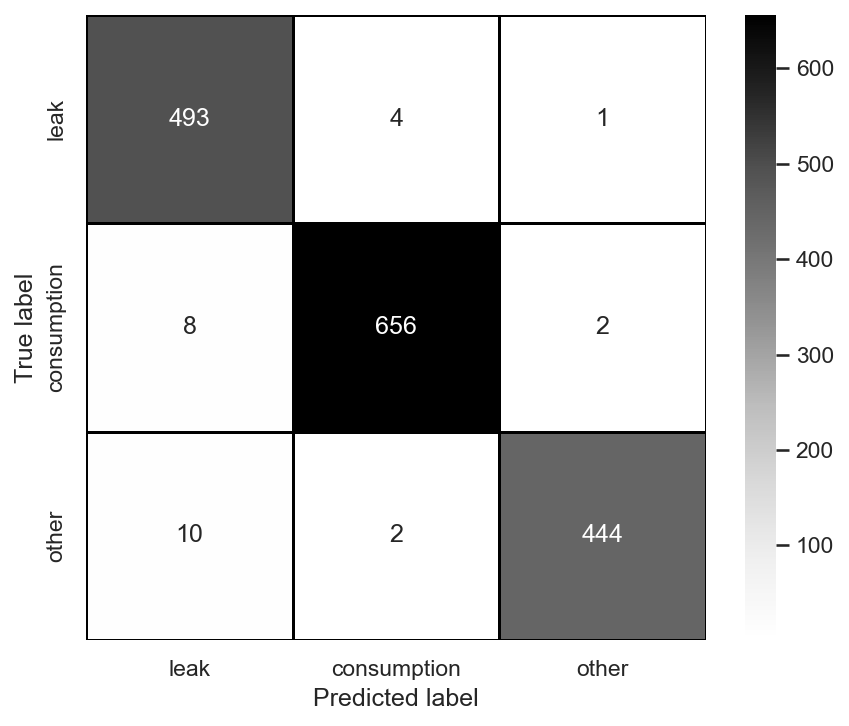

Saved: ../results/figures/training_curve.png and training_curve.pdf


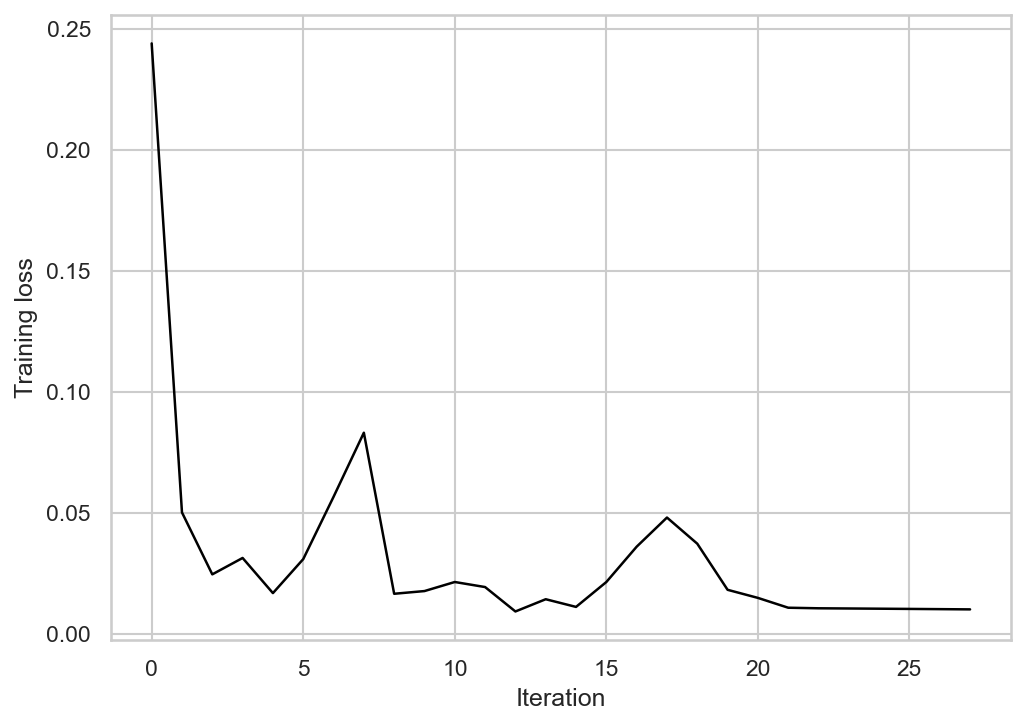

   noise_sigma  accuracy_mean  accuracy_std
0         0.00         0.9833        0.0000
1         0.02         0.9836        0.0011
2         0.05         0.9835        0.0015
3         0.10         0.9833        0.0009
4         0.15         0.9796        0.0025
5         0.20         0.9786        0.0008
6         0.30         0.9748        0.0013
7         0.40         0.9640        0.0048
8         0.50         0.9360        0.0029

Saved: ../results/tables/robustness_noise.csv
Saved: ../results/figures/robustness_curve.png and robustness_curve.pdf


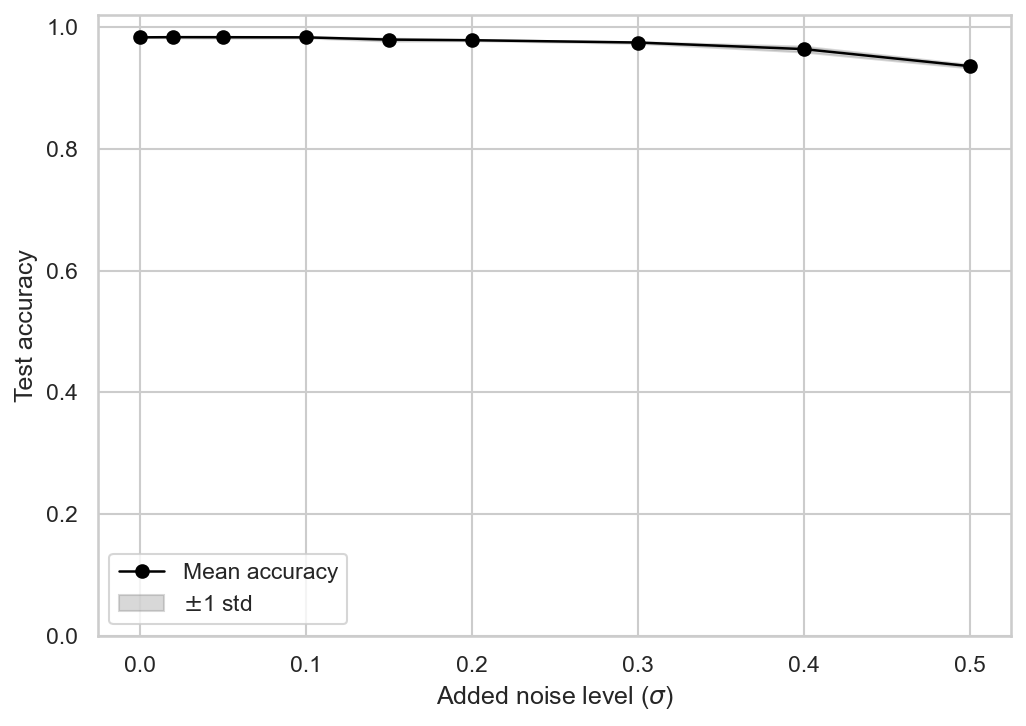

In [2]:
# ============================================================
# Notebook: 03_cnn_classification.ipynb
# Purpose : Train a lightweight neural-network classifier (MLP on
#           flattened spectrograms) to classify spectrograms into
#           leak / consumption / other. Uses group-aware train/test
#           splitting (by source signal id) to prevent leakage of
#           augmented copies across the split. Reports accuracy,
#           per-class precision/recall/F1, and a confusion matrix.
#           Also evaluates robustness to added spectrogram noise.
#           Implemented with scikit-learn only (no deep-learning deps).
# Inputs  : ../data/spectrograms.npz
# Outputs : ../results/tables/classification_report.csv
#           ../results/tables/confusion_matrix.csv
#           ../results/tables/robustness_noise.csv
#           ../results/figures/confusion_matrix.(png/pdf)
#           ../results/figures/training_curve.(png/pdf)
#           ../results/figures/robustness_curve.(png/pdf)
# ============================================================

# ------------------------------------------------------------
# Cell 1 — Imports, configuration, and plotting helper
# ------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)

SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

DATA_DIR = "../data"
FIG_DIR = "../results/figures"
TAB_DIR = "../results/tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

# Global plotting style: seaborn, grayscale
sns.set_theme(style="whitegrid")
sns.set_palette("gray")
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.dpi"] = 150

def save_figure(fig, name, fig_dir=FIG_DIR, dpi=600):
    for ext in ("png", "pdf"):
        path = os.path.join(fig_dir, f"{name}.{ext}")
        fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {fig_dir}/{name}.png and {name}.pdf")


# ------------------------------------------------------------
# Cell 2 — Load spectrogram dataset
# ------------------------------------------------------------
data = np.load(os.path.join(DATA_DIR, "spectrograms.npz"), allow_pickle=True)
X_img = data["spec_images"]        # (N, H, W), float32 in [0, 1]
y_str = data["spec_labels"]        # (N,) string labels
groups = data["spec_ids"]          # (N,) source signal id per sample
IMG_SIZE = int(data["img_size"])

# Encode string labels to integer class indices (stable ordering)
CLASSES = ["leak", "consumption", "other"]
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
y = np.array([class_to_idx[s] for s in y_str], dtype=np.int64)

# Flatten each spectrogram image into a feature vector: (N, H*W)
N = X_img.shape[0]
X = X_img.reshape(N, -1)

print(f"Dataset: X={X.shape}, y={y.shape}, n_groups={len(np.unique(groups))}")


# ------------------------------------------------------------
# Cell 3 — Group-aware train/test split (7:3, no leakage)
# ------------------------------------------------------------
# Augmented copies share the source id in `groups`. GroupShuffleSplit
# guarantees that all samples from one source signal fall entirely in
# either train or test, never both.
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Sanity check: no group appears in both splits
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")


# ------------------------------------------------------------
# Cell 4 — Feature standardization
# ------------------------------------------------------------
# Standardize features using training statistics only, then apply the
# same transform to the test set (prevents information leakage).
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


# ------------------------------------------------------------
# Cell 5 — Lightweight neural-network classifier
# ------------------------------------------------------------
# A compact multilayer perceptron on flattened spectrograms. Two
# hidden layers keep the model lightweight and appropriate for
# synthetic data. early_stopping holds out part of the training set
# as an internal validation set to curb overfitting.
clf = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-3,                 # L2 regularization
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=SEED,
)
clf.fit(X_train_s, y_train)
print(f"Training stopped at iteration: {clf.n_iter_}")


# ------------------------------------------------------------
# Cell 6 — Evaluate on the test set
# ------------------------------------------------------------
y_pred = clf.predict(X_test_s)

acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}\n")

report_dict = classification_report(
    y_test, y_pred, target_names=CLASSES, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose().round(4)
print(report_df)

# Save the classification report as a table
report_df.to_csv(os.path.join(TAB_DIR, "classification_report.csv"))
print("\nSaved: ../results/tables/classification_report.csv")


# ------------------------------------------------------------
# Cell 7 — Confusion matrix (table + figure)
# ------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)
cm_df.to_csv(os.path.join(TAB_DIR, "confusion_matrix.csv"))
print("Saved: ../results/tables/confusion_matrix.csv")

# Grayscale heatmap, no title/caption
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greys", cbar=True,
            linewidths=0.5, linecolor="black", ax=ax)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
save_figure(fig, "confusion_matrix")
plt.show()


# ------------------------------------------------------------
# Cell 8 — Training loss curve (figure)
# ------------------------------------------------------------
# MLPClassifier records the training loss per iteration in loss_curve_.
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(clf.loss_curve_, color="black", linewidth=1.2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Training loss")
plt.tight_layout()
save_figure(fig, "training_curve")
plt.show()


# ------------------------------------------------------------
# Cell 9 — Robustness experiment: added noise on the test set
# ------------------------------------------------------------
# The trained classifier is fixed. We progressively inject additive
# Gaussian noise into the (unstandardized) test spectrograms to
# emulate harsher, noisier acquisition conditions, then re-apply the
# training scaler and measure accuracy. This probes how well the
# model generalizes beyond the noise level seen during training.
#
# Noise level is expressed as the standard deviation of Gaussian
# noise added to spectrogram intensities (which lie in [0, 1]).
NOISE_LEVELS = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
N_REPEATS = 5              # repeat each level to average out randomness

robust_rows = []
for sigma in NOISE_LEVELS:
    accs = []
    for r in range(N_REPEATS):
        noise = rng.normal(0, sigma, size=X_test.shape)
        X_noisy = np.clip(X_test + noise, 0.0, 1.0)   # keep valid range
        X_noisy_s = scaler.transform(X_noisy)         # same training scaler
        y_noisy_pred = clf.predict(X_noisy_s)
        accs.append(accuracy_score(y_test, y_noisy_pred))
    robust_rows.append({
        "noise_sigma": sigma,
        "accuracy_mean": np.mean(accs),
        "accuracy_std": np.std(accs),
    })

robust_df = pd.DataFrame(robust_rows).round(4)
robust_df.to_csv(os.path.join(TAB_DIR, "robustness_noise.csv"), index=False)
print(robust_df)
print("\nSaved: ../results/tables/robustness_noise.csv")


# ------------------------------------------------------------
# Cell 10 — Robustness curve (figure)
# ------------------------------------------------------------
# Accuracy vs added-noise level, with a shaded band for +/- 1 std
# across repeats. Grayscale, no title/caption.
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(robust_df["noise_sigma"], robust_df["accuracy_mean"],
        marker="o", color="black", linewidth=1.2, label="Mean accuracy")
ax.fill_between(
    robust_df["noise_sigma"],
    robust_df["accuracy_mean"] - robust_df["accuracy_std"],
    robust_df["accuracy_mean"] + robust_df["accuracy_std"],
    color="gray", alpha=0.3, label="$\\pm$1 std",
)
ax.set_xlabel("Added noise level ($\\sigma$)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(0, 1.02)
ax.legend()
plt.tight_layout()
save_figure(fig, "robustness_curve")
plt.show()